In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [17]:
df.shape

(46000, 3)

In [18]:
df['amfi_code'].nunique()

40

In [19]:
df['date'] = pd.to_datetime(df['date'])

In [20]:
df.dtypes

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

In [21]:
df = df.sort_values(
    ['amfi_code', 'date']
)

In [22]:
df.head(10)

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [23]:
df['daily_return'] = (
    df.groupby('amfi_code')['nav']
      .pct_change()
)

In [24]:
df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [25]:
df['daily_return'].isnull().sum()

np.int64(40)

In [26]:
df.to_csv(
    "../data/processed/nav_returns.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [27]:
df.groupby('amfi_code').agg({
    'date': ['min', 'max'],
    'nav': ['first', 'last']
}).head()

date                  nav          
                 min        max     first      last
amfi_code                                          
100016    2022-01-03 2026-05-29  520.4608  583.6113
100025    2022-01-03 2026-05-29   26.3169   31.8843
100033    2022-01-03 2026-05-29  107.3758  342.0072
101206    2022-01-03 2026-05-29  305.0996  773.2939
101207    2022-01-03 2026-05-29   38.5736   53.9836

In [29]:
def calculate_cagr(group):

    start_nav = group['nav'].iloc[0]

    end_nav = group['nav'].iloc[-1]

    years = (
        group['date'].iloc[-1]
        -
        group['date'].iloc[0]
    ).days / 365

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    return cagr

In [31]:
cagr_df = (
    df.groupby('amfi_code')
      .apply(calculate_cagr)
      .reset_index()
)

cagr_df

,amfi_code,0
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331
5,101208,0.065044
6,102885,0.182188
7,102886,0.011709
8,102887,0.168287
9,118632,0.240312


In [32]:
cagr_df.columns = [
    'amfi_code',
    'cagr'
]

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [33]:
cagr_df['cagr_percent'] = (
    cagr_df['cagr'] * 100
)

cagr_df.head()

,amfi_code,cagr,cagr_percent
0,100016,0.026352,2.635246
1,100025,0.044551,4.455091
2,100033,0.300997,30.099704
3,101206,0.235205,23.520489
4,101207,0.079331,7.933121


In [34]:
top_cagr = cagr_df.sort_values(
    by='cagr',
    ascending=False
)

top_cagr.head(10)

,amfi_code,cagr,cagr_percent
25,120505,0.328016,32.801599
21,119598,0.323981,32.398084
39,149324,0.322621,32.262108
36,148569,0.319245,31.924486
34,148567,0.309499,30.949920
30,120843,0.308833,30.883326
2,100033,0.300997,30.099704
38,149323,0.295581,29.558105
16,119094,0.281926,28.192608
19,119551,0.257849,25.784921


In [37]:
cagr_df.to_csv("../data/processed/cagr.csv", index=False)

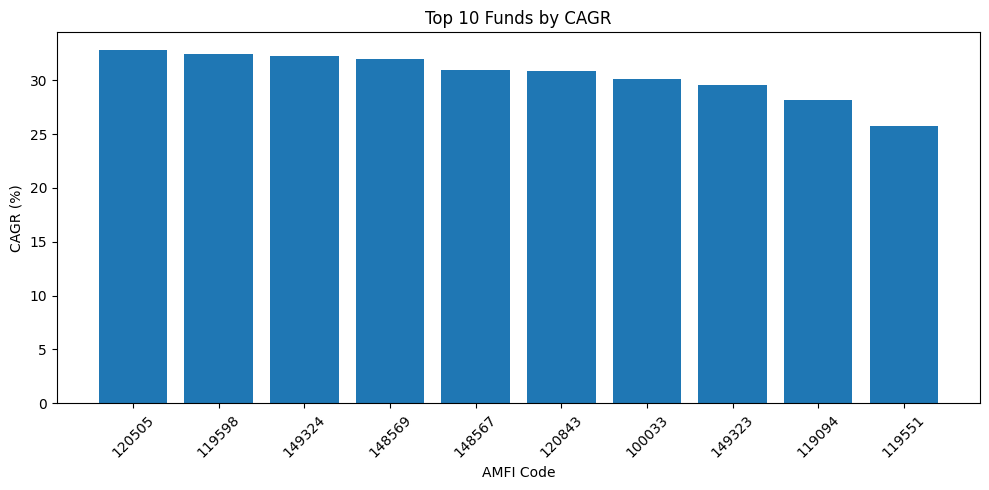

In [41]:
top10 = top_cagr.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10['amfi_code'].astype(str),
    top10['cagr_percent']
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.xticks(rotation=45)

plt.tight_layout()

# SAVE FIRST
plt.savefig("../reports/top10_cagr.png",dpi=300, bbox_inches="tight")

# THEN SHOW
plt.show()

In [42]:
rf = 0.065

daily_rf = rf / 252

print(daily_rf)

0.00025793650793650796


In [43]:
def calculate_sharpe(group):

    mean_return = group['daily_return'].mean()

    std_return = group['daily_return'].std()

    sharpe = (
        (mean_return - daily_rf)
        /
        std_return
    ) * np.sqrt(252)

    return sharpe

In [44]:
sharpe_df = (
    df.groupby('amfi_code')
      .apply(calculate_sharpe)
      .reset_index()
)

sharpe_df.head()

,amfi_code,0
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [45]:
sharpe_df.columns = [
    'amfi_code',
    'sharpe_ratio'
]

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [46]:
top_sharpe = sharpe_df.sort_values(
    by='sharpe_ratio',
    ascending=False
)

top_sharpe.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [47]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Saved")

Sharpe Ratio Saved


In [48]:
def calculate_sortino(group):

    mean_return = group['daily_return'].mean()

    downside_returns = group[
        group['daily_return'] < 0
    ]['daily_return']

    downside_std = downside_returns.std()

    sortino = (
        (mean_return - daily_rf)
        /
        downside_std
    ) * np.sqrt(252)

    return sortino

In [49]:
sortino_df = (
    df.groupby('amfi_code')
      .apply(calculate_sortino)
      .reset_index()
)

sortino_df.head()

,amfi_code,0
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [50]:
sortino_df.columns = [
    'amfi_code',
    'sortino_ratio'
]

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [51]:
top_sortino = sortino_df.sort_values(
    by='sortino_ratio',
    ascending=False
)

top_sortino.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [52]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio Saved")

Sortino Ratio Saved


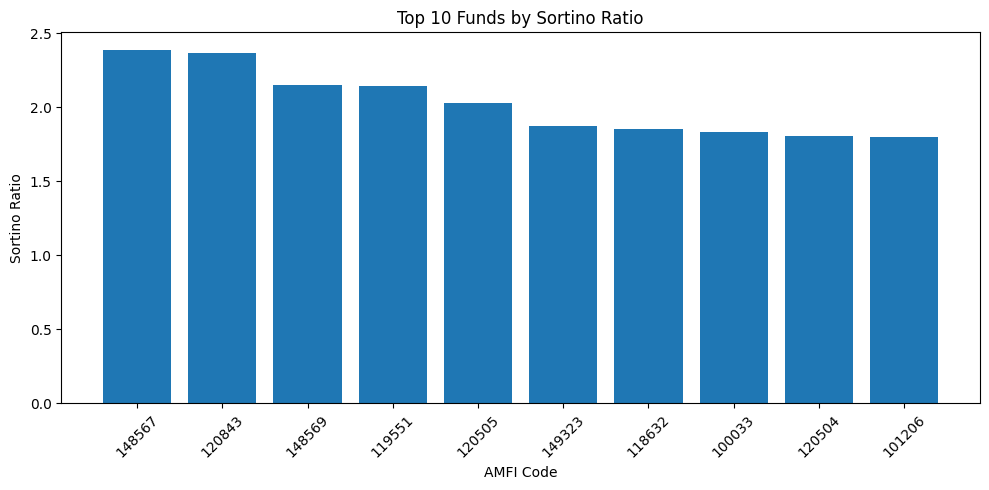

In [53]:
top10 = top_sortino.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10['amfi_code'].astype(str),
    top10['sortino_ratio']
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/top10_sortino.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
benchmark_df = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [55]:
benchmark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [56]:
benchmark_df.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [57]:
benchmark_df['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [58]:
benchmark_df['index_name'].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [59]:
nifty100 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [61]:
nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [62]:
nifty100 = nifty100.sort_values('date')

In [63]:
nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [64]:
from scipy.stats import linregress

In [65]:
def calculate_alpha_beta(group):

    merged = pd.merge(
        group,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) < 30:
        return pd.Series({
            'alpha': np.nan,
            'beta': np.nan
        })

    slope, intercept, r_value, p_value, std_err = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    beta = slope

    alpha = intercept * 252

    return pd.Series({
        'alpha': alpha,
        'beta': beta
    })

In [66]:
alpha_beta_df = (
    df.groupby('amfi_code')
      .apply(calculate_alpha_beta)
      .reset_index()
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [67]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha Beta Saved Successfully")

Alpha Beta Saved Successfully


In [68]:
top_alpha = alpha_beta_df.sort_values(
    by='alpha',
    ascending=False
)

top_alpha.head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


In [69]:
low_beta = alpha_beta_df.sort_values(
    by='beta'
)

low_beta.head(10)

,amfi_code,alpha,beta
17,119095,0.048016,-0.066951
16,119094,0.260767,-0.066265
4,101207,0.108971,-0.065289
0,100016,0.037476,-0.058268
7,102886,0.028969,-0.042125
23,120503,0.177033,-0.040269
10,118633,0.156438,-0.036639
19,119551,0.232010,-0.031751
35,148568,0.208730,-0.026388
20,119552,0.198686,-0.026159


In [70]:
def calculate_max_drawdown(group):

    running_max = group['nav'].cummax()

    drawdown = (
        group['nav']
        /
        running_max
    ) - 1

    max_dd = drawdown.min()

    return max_dd

In [71]:
max_dd_df = (
    df.groupby('amfi_code')
      .apply(calculate_max_drawdown)
      .reset_index()
)

max_dd_df.columns = [
    'amfi_code',
    'max_drawdown'
]

max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [72]:
max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Saved")

Maximum Drawdown Saved


In [73]:
best_dd = max_dd_df.sort_values(
    by='max_drawdown',
    ascending=False
)

best_dd.head(10)

,amfi_code,max_drawdown
27,120507,-0.000977
31,120844,-0.001163
5,101208,-0.001622
1,100025,-0.043083
18,119120,-0.043287
13,118636,-0.083164
6,102885,-0.108599
34,148567,-0.112657
3,101206,-0.112916
12,118635,-0.116506


In [74]:
scheme_df = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

scheme_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [75]:
scheme_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'anomaly'],
      dtype='str')

In [76]:
scorecard_df = scheme_df.copy()

scorecard_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [77]:
scorecard_df['return_rank'] = (
    scorecard_df['return_3yr_pct']
    .rank(ascending=False)
)

scorecard_df['sharpe_rank'] = (
    scorecard_df['sharpe_ratio']
    .rank(ascending=False)
)

scorecard_df['alpha_rank'] = (
    scorecard_df['alpha']
    .rank(ascending=False)
)

scorecard_df['expense_rank'] = (
    scorecard_df['expense_ratio_pct']
    .rank(ascending=True)
)

scorecard_df['drawdown_rank'] = (
    scorecard_df['max_drawdown_pct']
    .rank(ascending=True)
)

In [78]:
scorecard_df['fund_score'] = (

    scorecard_df['return_rank'] * 0.30 +

    scorecard_df['sharpe_rank'] * 0.25 +

    scorecard_df['alpha_rank'] * 0.20 +

    scorecard_df['expense_rank'] * 0.15 +

    scorecard_df['drawdown_rank'] * 0.10

)

In [79]:
scorecard_df = scorecard_df.sort_values(
    by='fund_score'
)

scorecard_df.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,expense_ratio_pct,morningstar_rating,risk_grade,anomaly,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.72,4,Very High,False,2.0,19.5,22.5,5.5,11.0,11.900
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.45,5,Moderately High,False,11.0,12.0,3.5,22.0,21.0,12.400
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,1.56,4,High,False,7.0,15.0,2.0,33.0,16.0,12.800
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,1.53,5,Very High,False,3.0,24.5,5.0,28.5,14.0,13.700
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.43,5,Very High,False,1.0,18.0,20.0,21.0,33.0,15.250
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.46,5,Moderate,False,17.0,7.5,12.0,23.0,26.0,15.425
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,0.56,3,Low,False,36.0,4.0,1.0,2.0,35.0,15.800
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,0.74,5,Low,False,35.0,1.0,3.5,7.0,38.0,16.300
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,1.36,3,High,False,8.0,17.0,29.5,15.0,18.0,16.600
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,0.80,3,Moderate,False,20.0,9.0,31.0,12.0,9.0,17.150


In [80]:
scorecard_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


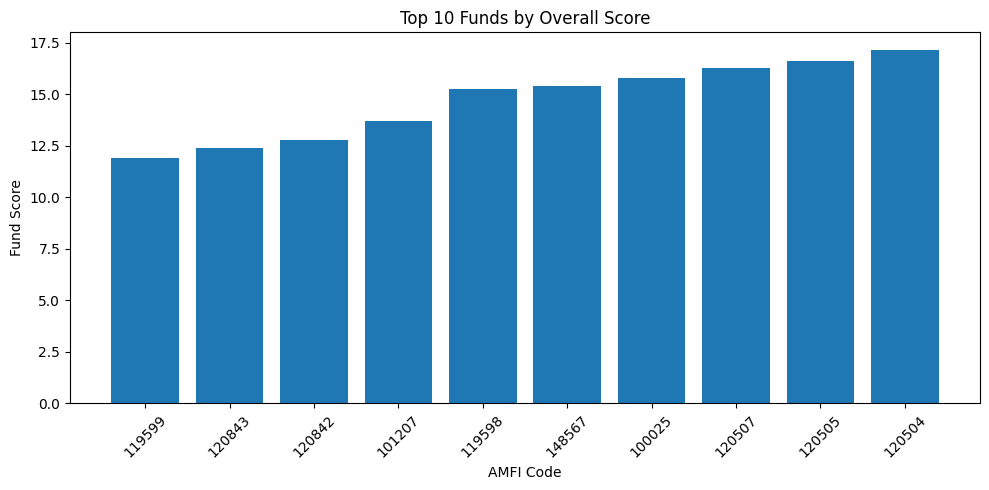

In [81]:
import matplotlib.pyplot as plt

top10 = scorecard_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10['amfi_code'].astype(str),
    top10['fund_score']
)

plt.title("Top 10 Funds by Overall Score")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:
print(top5_codes)
print(top5_nav.shape)

[148569, 120503, 119551, 120841, 119092]
(5750, 5)


In [91]:
top5_funds = scorecard_df.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5_funds

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,expense_ratio_pct,morningstar_rating,risk_grade,anomaly,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,...,1.60,5,High,False,23.0,38.5,39.0,36.5,15.0,31.300
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,...,1.42,4,Moderate,False,33.0,33.5,37.0,20.0,10.0,29.675
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.54,4,Moderate,False,26.0,26.5,32.0,30.5,19.5,27.350
20,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Large Cap,Regular,14.37,12.25,13.42,10.98,1.27,...,1.59,3,Moderate,False,28.0,29.0,19.0,35.0,23.0,27.000
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,...,1.64,4,Moderate,False,31.0,31.0,17.0,39.5,6.0,26.975


In [92]:
top5_codes = top5_funds["amfi_code"].tolist()

top5_codes

[148569, 120503, 119551, 120841, 119092]

In [93]:
top5_nav = df[
    df["amfi_code"].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
16100,119092,2022-01-03,38.7466,NaN
16101,119092,2022-01-04,38.4924,-0.006561
16102,119092,2022-01-05,38.2033,-0.007511
16103,119092,2022-01-06,38.5825,0.009926
16104,119092,2022-01-07,38.9425,0.009331


In [94]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [96]:
nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

nifty50.head()

,date,index_name,close_value,normalized
0,2022-01-03,NIFTY50,17492.79,100.000000
1,2022-01-04,NIFTY50,17689.64,101.125321
2,2022-01-05,NIFTY50,17835.05,101.956578
3,2022-01-06,NIFTY50,17878.51,102.205023
4,2022-01-07,NIFTY50,17759.15,101.522684


In [97]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    * 100
)

nifty100.head()

,date,index_name,close_value,normalized
1150,2022-01-03,NIFTY100,17778.24,100.000000
1151,2022-01-04,NIFTY100,17537.52,98.645985
1152,2022-01-05,NIFTY100,17607.73,99.040906
1153,2022-01-06,NIFTY100,17556.05,98.750214
1154,2022-01-07,NIFTY100,17664.02,99.357529


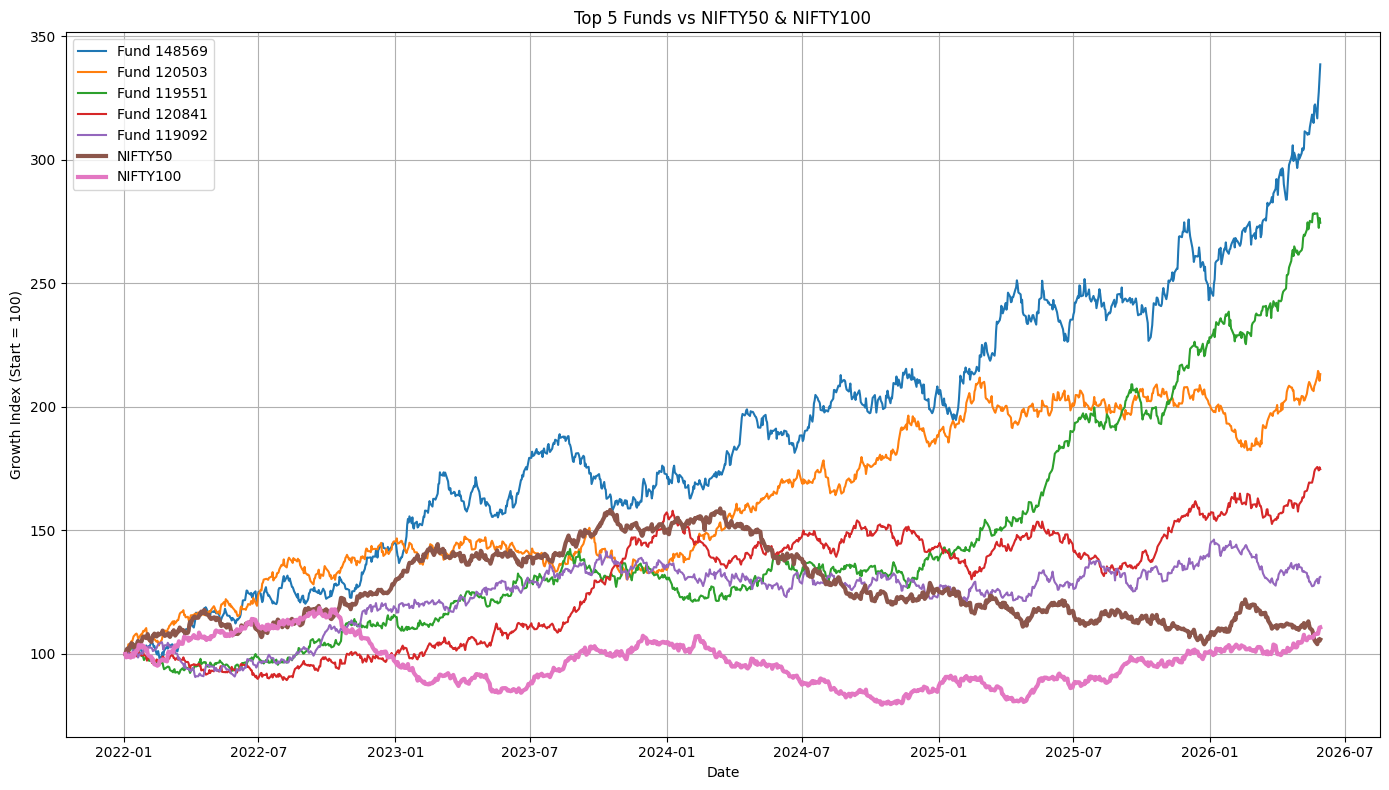

In [98]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    fund_data = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        fund_data["date"],
        fund_data["normalized_nav"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Growth Index (Start = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
import os

print(os.path.exists("../data/processed/fund_scorecard.csv"))
print(os.path.exists("../data/processed/alpha_beta.csv"))
print(os.path.exists("../reports/benchmark_comparison.png"))

True
True
True
